In [1]:
import json
import sys
import os

import pandas as pd

sys.path.append(os.path.abspath(".."))

# import top 25 CWEs
with open("../data/raw/top_25_cwe_data.json", "r", encoding="utf-8") as f:
    cwe_data = json.load(f)

TOP_25_CWES = cwe_data["TOP_25_CWES"]

# build CWE map for TOSEM
with open("../data/raw/tool_assisted_manual_dataset.json") as f:
    dataset = json.load(f)

rows = []
for entry in dataset:
    cwe = entry.get("cwe", "Unknown")
    for commit in entry.get("fixing", []):
        rows.append({"commit_id": commit, "cwe": cwe})
    intro = entry.get("introducing")
    if intro:
        rows.append({"commit_id": intro, "cwe": cwe})

df_cwe_map = pd.DataFrame(rows)

# merge to get CWEs
df_tosem = pd.read_csv("../data/intermediate/churn_tosem.csv")
df_tosem = df_tosem.merge(df_cwe_map, on="commit_id", how="left")

df_tosem_filtered = df_tosem[df_tosem["cwe"].isin(TOP_25_CWES)]

In [2]:
import pandas as pd
import ast

# Load both
df_icvul = pd.read_csv("../data/intermediate/churn_icvul.csv")
df_icvul_raw = pd.read_csv("../data/raw/icvul.csv")

# fc_hash lookup
fc_lookup = df_icvul_raw[["fc_hash", "cwe_id"]].rename(columns={"fc_hash": "commit_id"})

# vcc_hash lookup
df_icvul_raw["vcc_hash"] = df_icvul_raw["vcc_hash"].apply(ast.literal_eval)
vcc_lookup = df_icvul_raw.explode("vcc_hash")[["vcc_hash", "cwe_id"]].rename(columns={"vcc_hash": "commit_id"})

# Combine both lookups
commit_to_cwe = pd.concat([fc_lookup, vcc_lookup]).drop_duplicates(subset="commit_id")

# Merge into processed ICVul df
df_icvul = df_icvul.merge(commit_to_cwe, on="commit_id", how="left")

# Filter to top 25
df_icvul_filtered = df_icvul[df_icvul["cwe_id"].isin(TOP_25_CWES)]
df_icvul_filtered = df_icvul_filtered.rename(columns={"cwe_id": "cwe"})

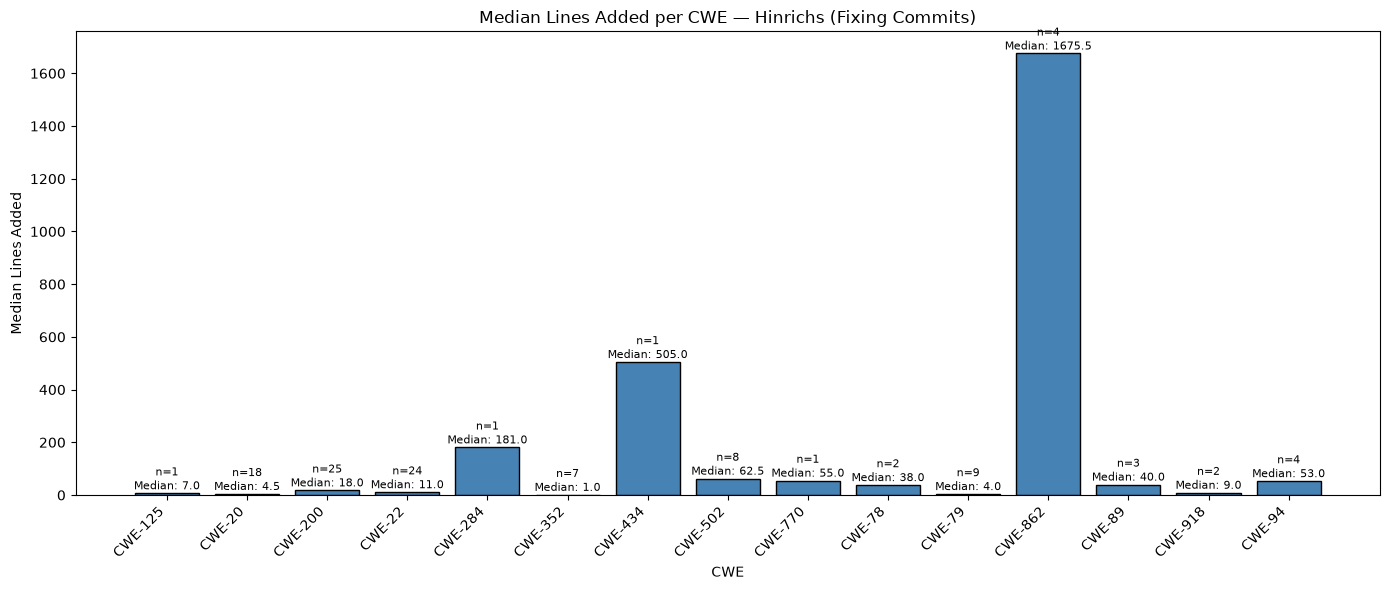

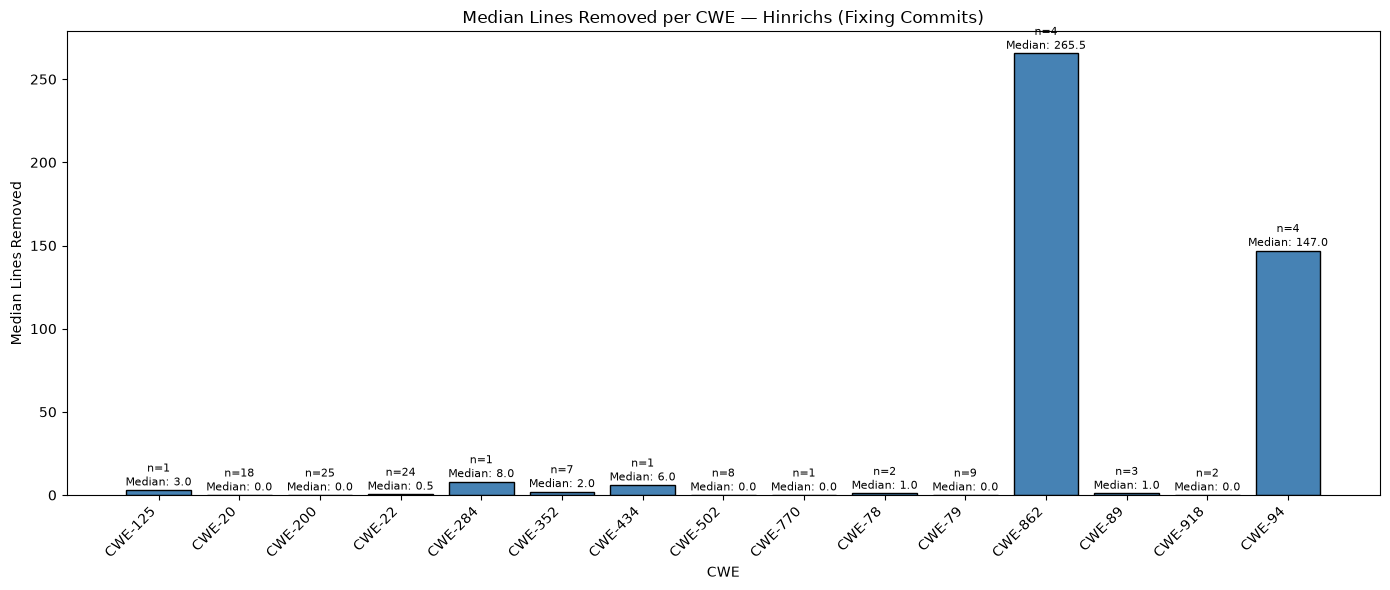

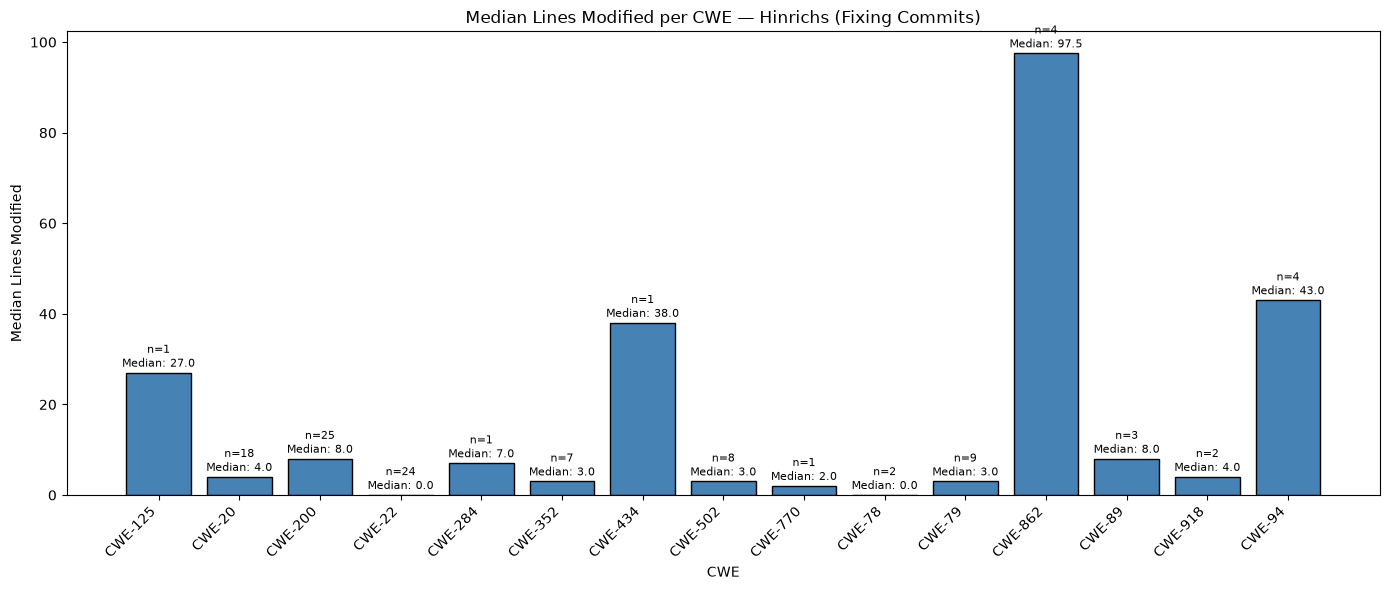

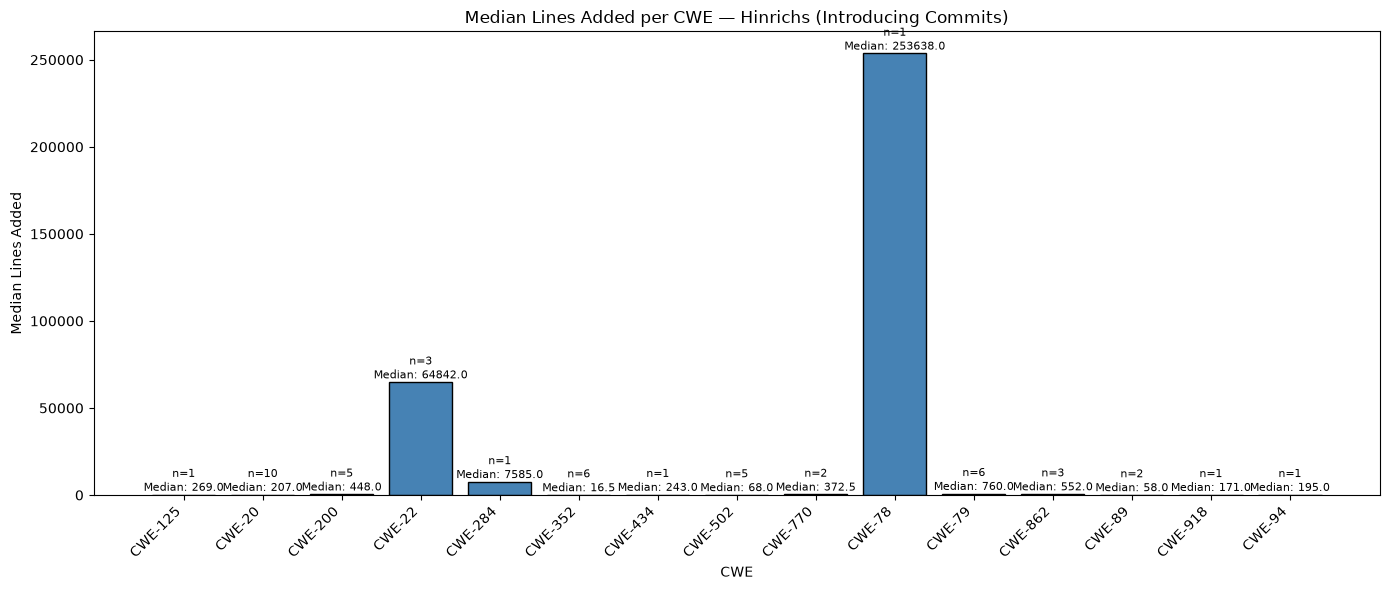

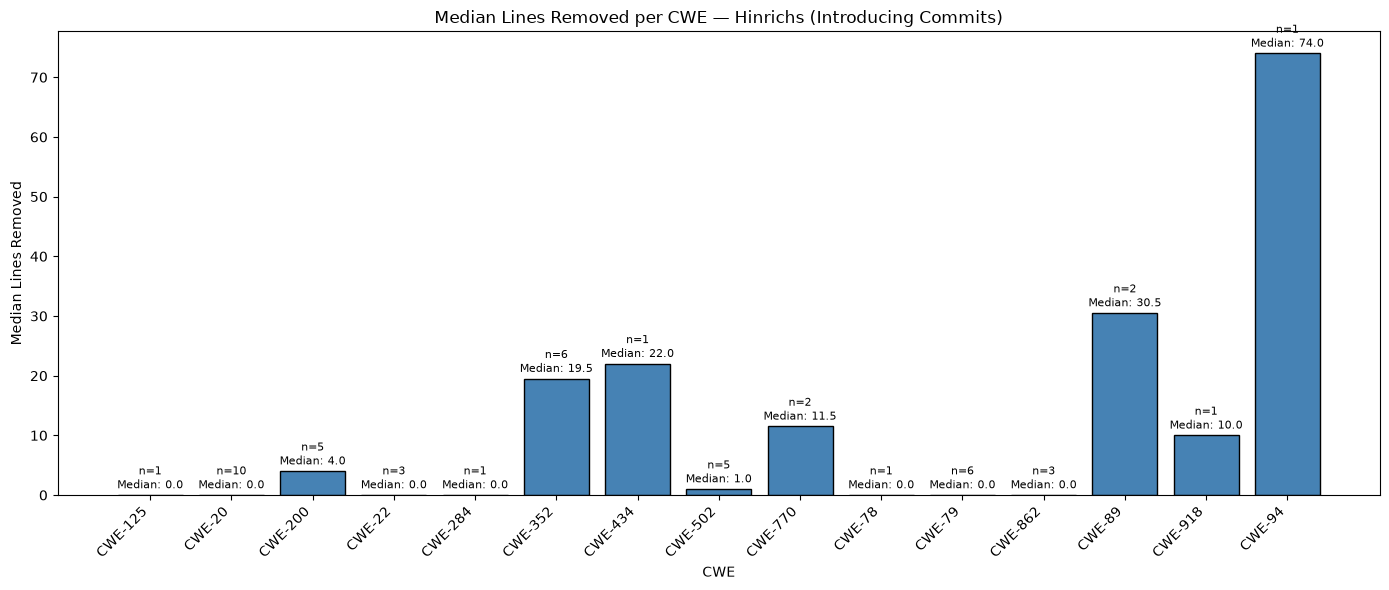

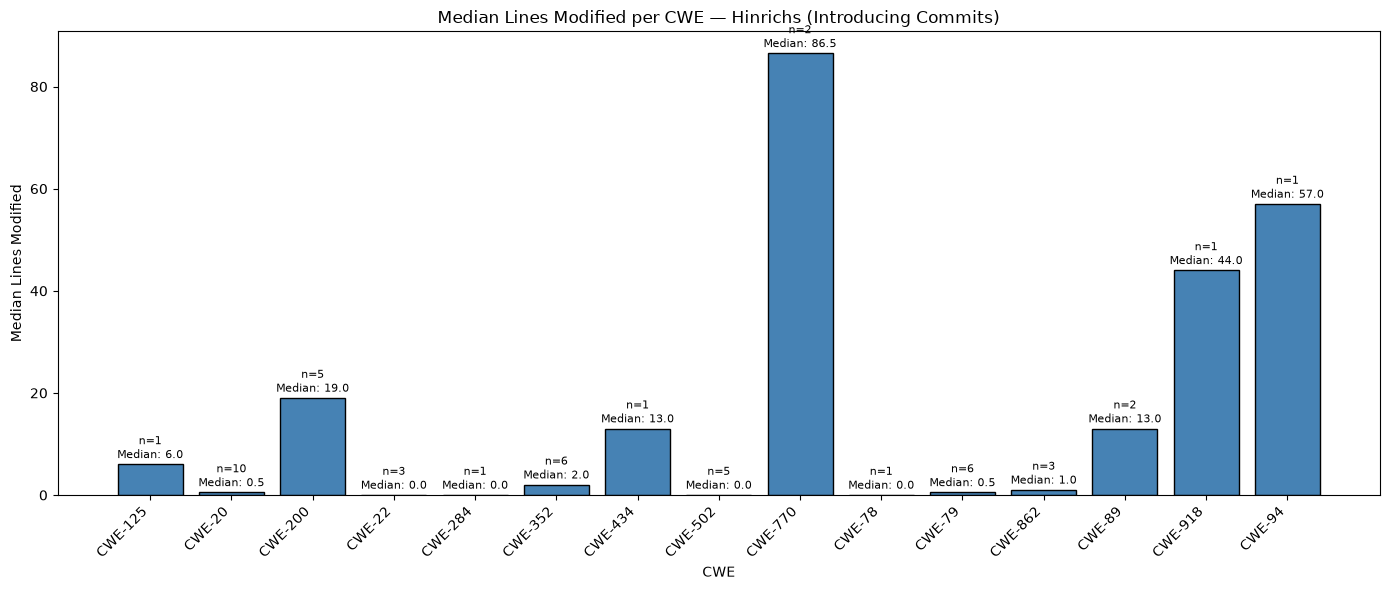

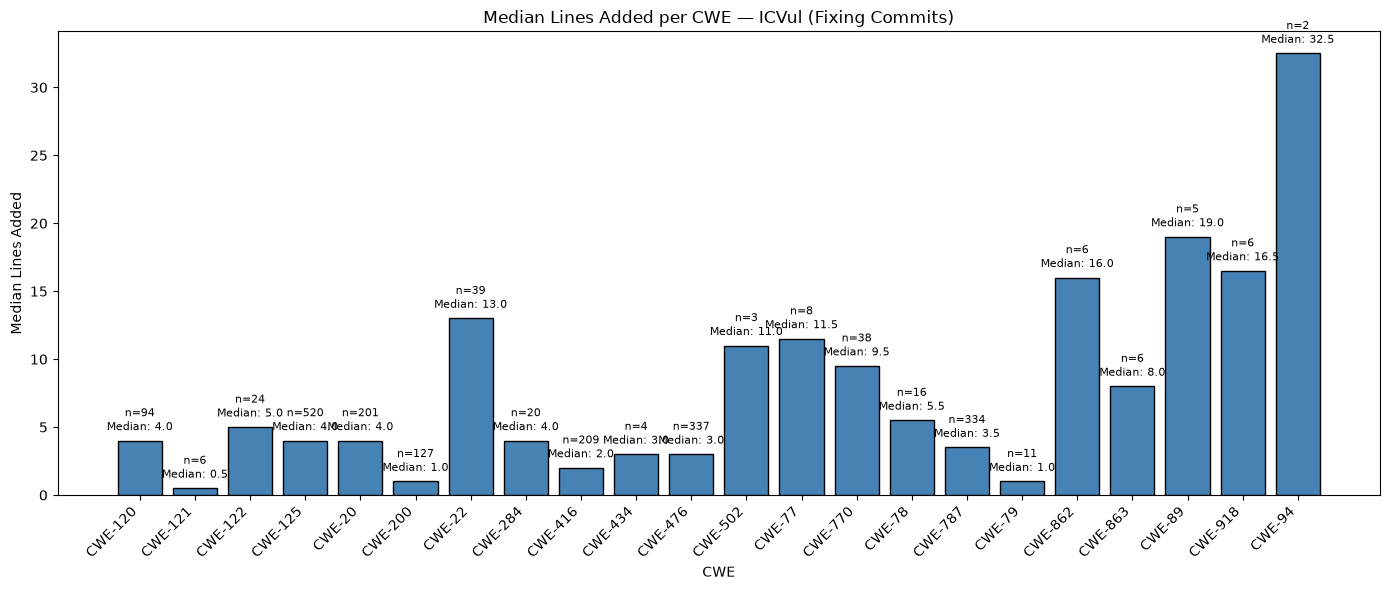

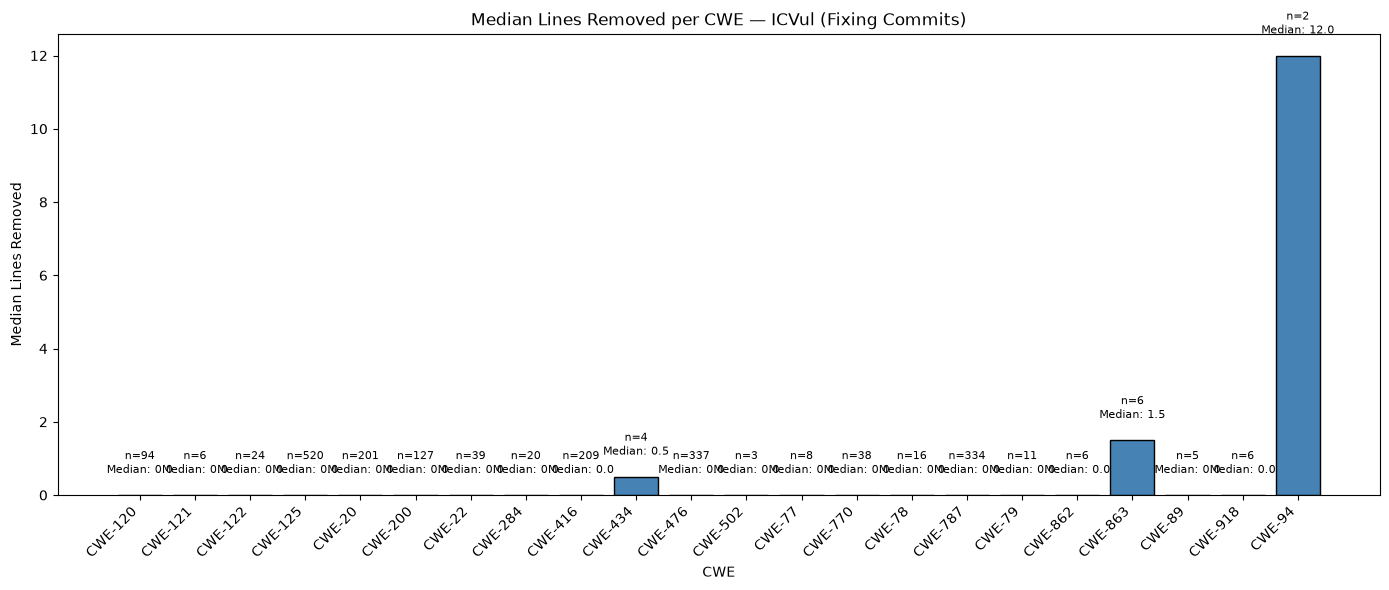

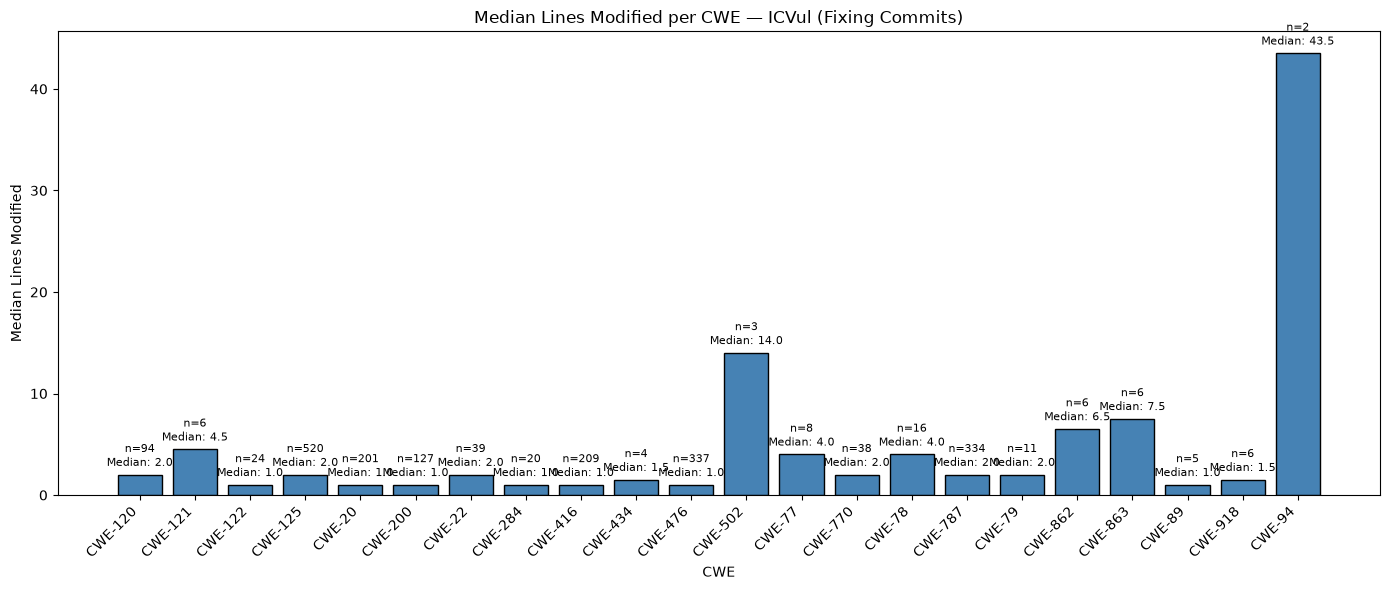

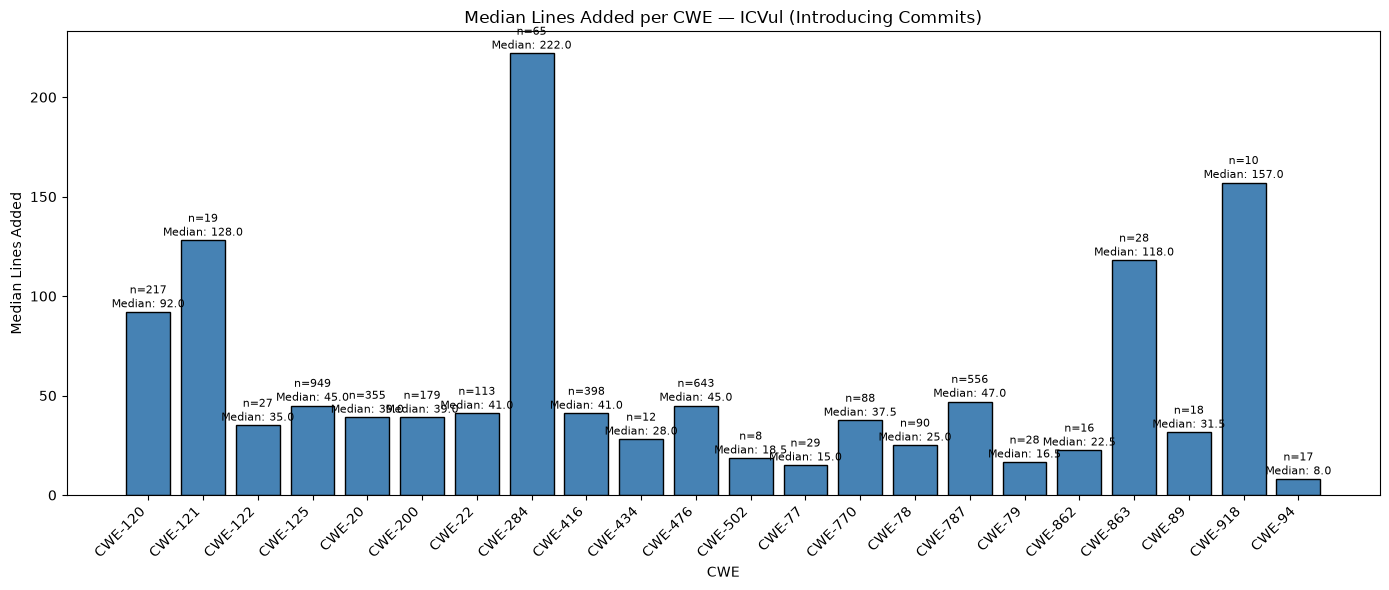

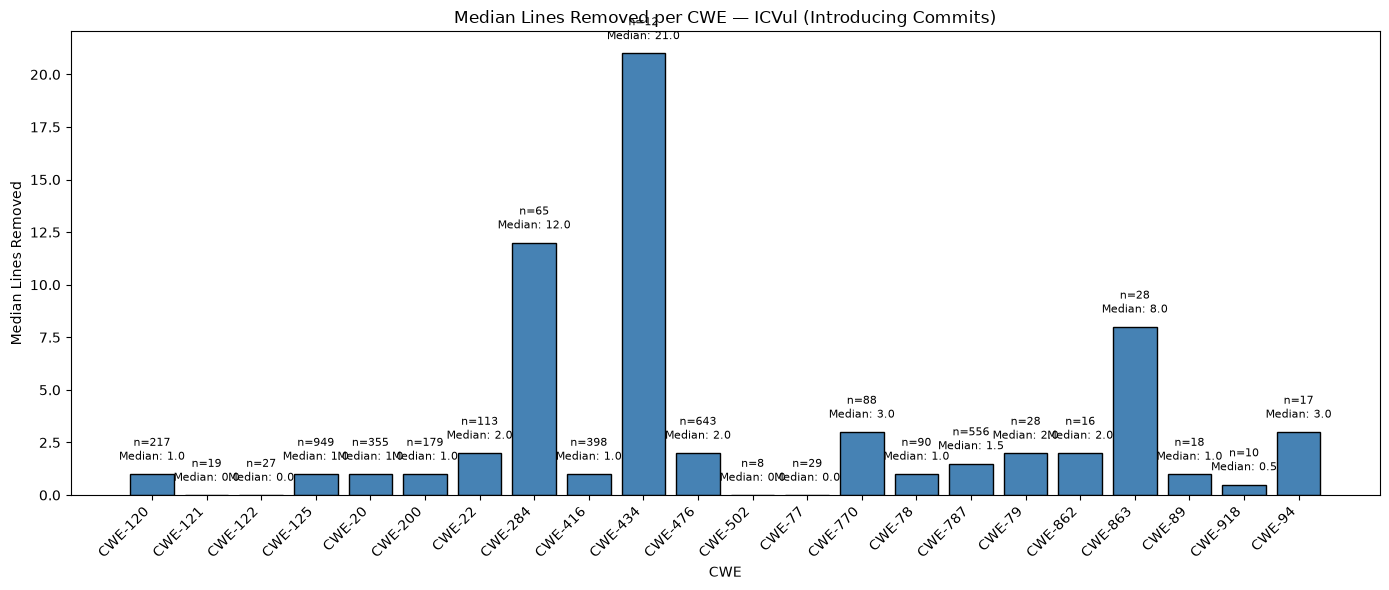

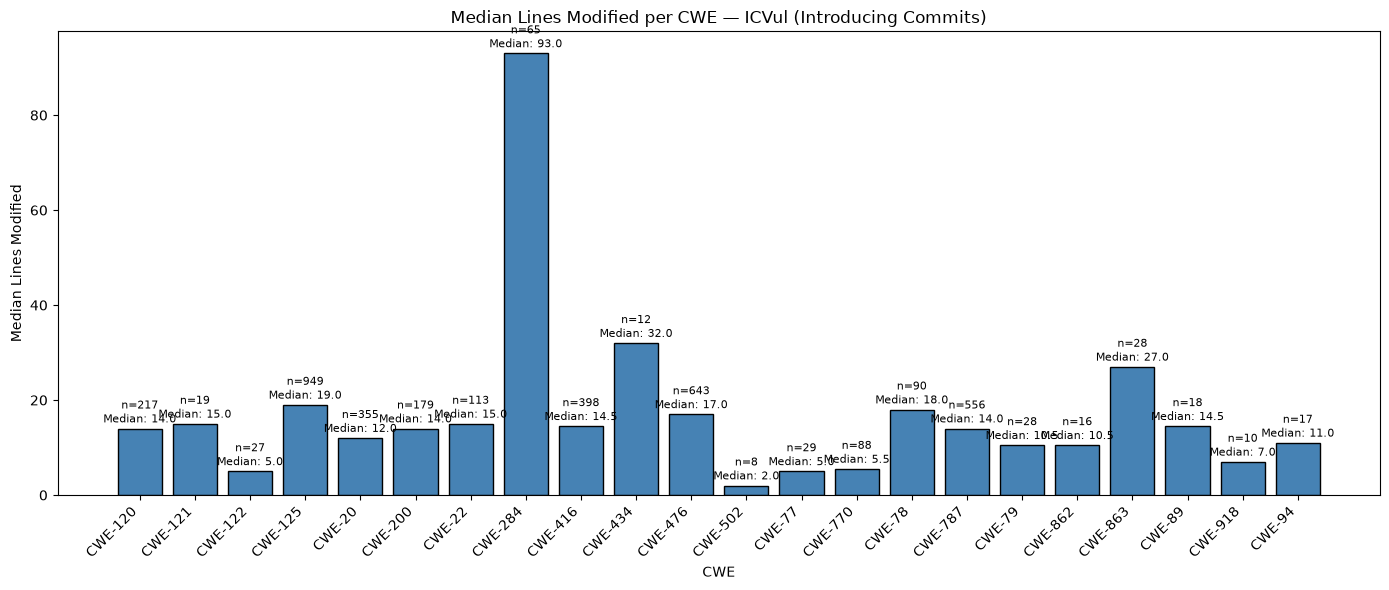

In [3]:
from utils.plot import plot_cwe_median

# TOSEM
plot_cwe_median(df_tosem_filtered, "Hinrichs", "VFC")
plot_cwe_median(df_tosem_filtered, "Hinrichs", "VIC")

# ICVul
plot_cwe_median(df_icvul_filtered, "ICVul", "VFC")
plot_cwe_median(df_icvul_filtered, "ICVul", "VIC")

In [4]:
churn_cols = ["lines_added", "lines_removed", "lines_modified"]

df_h = df_tosem_filtered.copy()
df_h["dataset"] = "Hinrichs"

df_i = df_icvul_filtered.copy()
df_i["dataset"] = "ICVul"

df_all = pd.concat([df_h, df_i], ignore_index=True)
df_all["total_churn"] = df_all[churn_cols].sum(axis=1)

# sanity check — make sure commit_role exists and has expected values
print(df_all["commit_role"].value_counts(dropna=False))
print(df_all["total_churn"].describe())

commit_role
VIC    3913
VFC    2126
Name: count, dtype: int64
count    6.039000e+03
mean     4.233715e+03
std      1.089634e+05
min      0.000000e+00
25%      7.000000e+00
50%      3.800000e+01
75%      2.390000e+02
max      7.565900e+06
Name: total_churn, dtype: float64


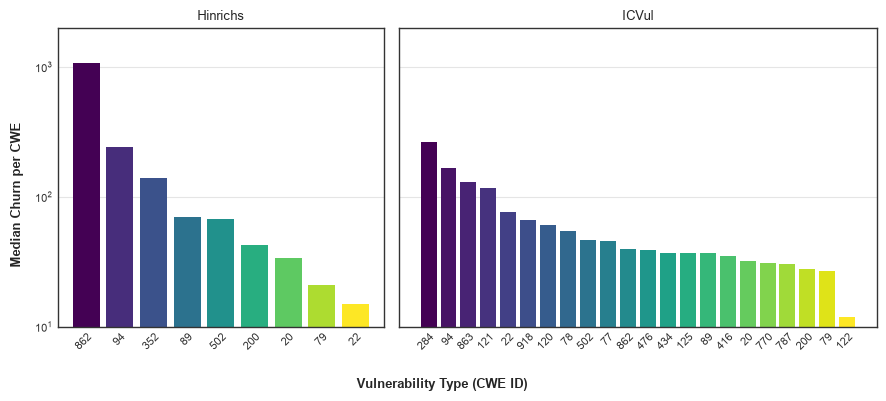

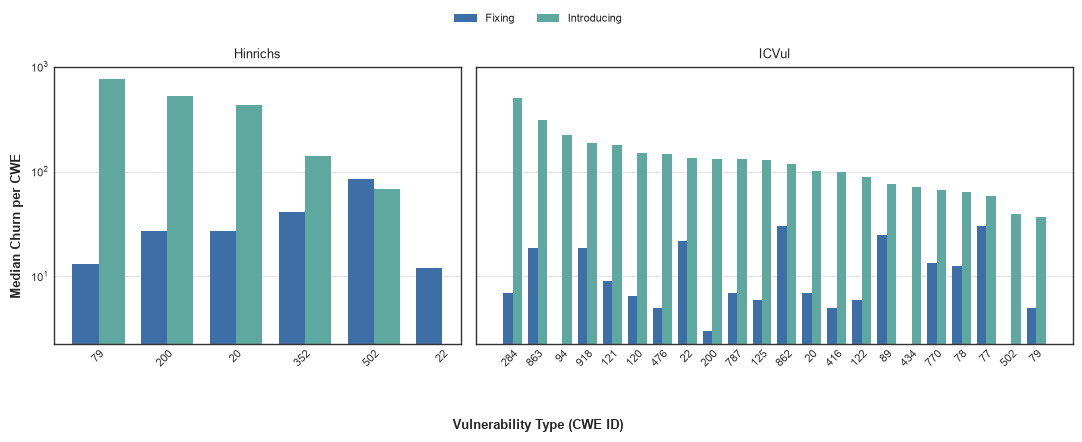

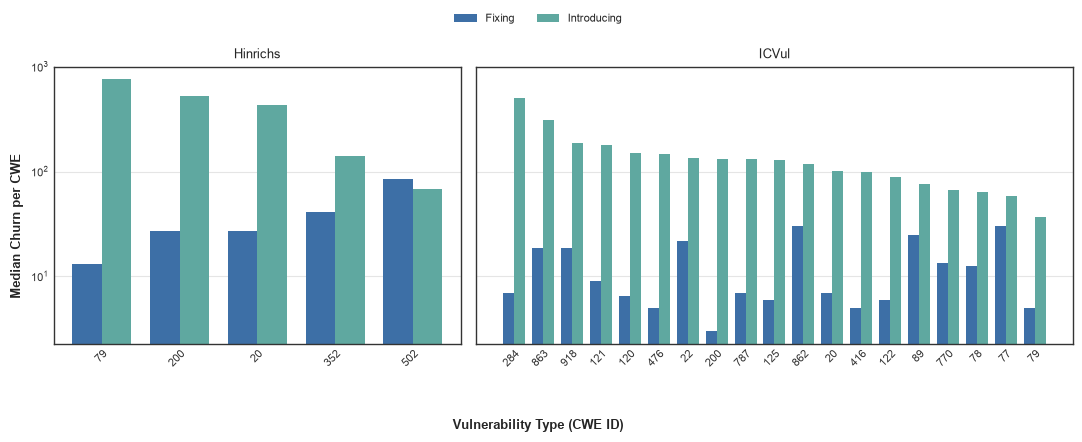

In [5]:
import matplotlib.pyplot as plt
plt.style.use(['seaborn-v0_8-whitegrid'])

import importlib, utils.plot
importlib.reload(utils.plot)
from utils.plot import plot_cwe_single, plot_cwe_paired

n_hinrichs = df_all[(df_all["dataset"] == "Hinrichs")]["cwe"].nunique()
n_icvul = df_all[(df_all["dataset"] == "ICVul")]["cwe"].nunique()

# feel free to play around with n_min - currently set to 5
n_min = 5

# (a) plain single bar
fig, axes = plt.subplots(1, 2, figsize=(9, 4), gridspec_kw={"width_ratios": [n_hinrichs, n_icvul]}, sharey=True)
plot_cwe_single(df_all, "Hinrichs", axes[0], n_min=n_min)
plot_cwe_single(df_all, "ICVul", axes[1], n_min=n_min)
fig.supylabel("Median Churn per CWE", fontsize=9, fontweight="bold")
fig.supxlabel("Vulnerability Type (CWE ID)", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.show()

# (b) paired bar - version 1
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2),
                          gridspec_kw={"width_ratios": [n_hinrichs, n_icvul]}, sharey=True)  # match actual surviving CWE counts once known
bars_fix, bars_intro = plot_cwe_paired(df_all, "Hinrichs", axes[0], n_min, False)
plot_cwe_paired(df_all, "ICVul", axes[1], n_min, False)
fig.supylabel("Median Churn per CWE", fontsize=9, fontweight="bold")
fig.supxlabel("Vulnerability Type (CWE ID)", fontsize=9, fontweight="bold")
fig.legend(
    [bars_fix, bars_intro],
    ["Fixing", "Introducing"],
    loc="upper center",
    bbox_to_anchor=(0.5, 1.03),  # Positioned cleanly above titles
    ncol=2,
    fontsize=8,
    frameon=False,
)
plt.tight_layout()
fig.subplots_adjust(
    top=0.88, bottom=0.22
)
plt.show()

# (b) paired bar - version 2
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2),
                          gridspec_kw={"width_ratios": [n_hinrichs, n_icvul]}, sharey=True)  # match actual surviving CWE counts once known
bars_fix, bars_intro = plot_cwe_paired(df_all, "Hinrichs", axes[0], n_min, True)
plot_cwe_paired(df_all, "ICVul", axes[1], n_min, True)
fig.supylabel("Median Churn per CWE", fontsize=9, fontweight="bold")
fig.supxlabel("Vulnerability Type (CWE ID)", fontsize=9, fontweight="bold")
fig.legend(
    [bars_fix, bars_intro],
    ["Fixing", "Introducing"],
    loc="upper center",
    bbox_to_anchor=(0.5, 1.03),  # Positioned cleanly above titles
    ncol=2,
    fontsize=8,
    frameon=False,
)
plt.tight_layout()
fig.subplots_adjust(
    top=0.88, bottom=0.22
)
plt.show()